In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K
import tensorflow as tf

In [23]:
# -----------------------------
# 1. Cargar datos preprocesados
# -----------------------------
ruta_csv = r"C:\\Users\\USER\\OneDrive - universidadean.edu.co\\2. Semestre\\Seminario de investigación\\Modulo 2\\Modelo ML\\data\\processed\\df_preprocesado_LSTM.csv"
df = pd.read_csv(ruta_csv, parse_dates=['FECHA_CIERRE'])

# Convertir booleanos
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)


In [24]:
# -----------------------------
# 2. Crear secuencias 3D
# -----------------------------
timesteps = 10
target_col = 'ETIQUETA_MORA'
feature_cols = df.select_dtypes(include=[np.number]).columns.difference([target_col, 'NUMERO DE LA COLOCACION'])

df = df.sort_values(['NUMERO DE LA COLOCACION', 'FECHA_CIERRE'])

X_sequences, y_targets, mora_actuales = [], [], []

for _, group in df.groupby('NUMERO DE LA COLOCACION'):
    group = group.reset_index(drop=True)
    for i in range(len(group) - timesteps):
        X_seq = group.loc[i:i+timesteps-1, feature_cols].values
        y_val = group.loc[i+timesteps, target_col]
        mora_val = group.loc[i+timesteps-1, 'MORA_ACTUAL']

        if not np.isnan(X_seq).any() and not pd.isna(y_val):
            X_sequences.append(X_seq)
            y_targets.append(y_val)
            mora_actuales.append(mora_val)

X_lstm = np.array(X_sequences)
y_lstm = np.array(y_targets)
mora_actual_lstm = np.array(mora_actuales)


In [25]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Aplanar X a 2D para SMOTE
X_flat = X_lstm.reshape((X_lstm.shape[0], -1))

# Guardar mora_actual_lstm original
mora_actual_lstm = df['MORA_ACTUAL'].values[timesteps:]  # mismo índice que y_lstm

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_lstm)

# Alinear mora_actual con y_resampled
# Generamos la misma cantidad que y_resampled por cada clase
counts = Counter(y_lstm)
target_counts = Counter(y_resampled)

# Distribuir proporcionalmente según la cantidad original de cada clase
idx_by_class = {label: np.where(y_lstm == label)[0] for label in np.unique(y_lstm)}

mora_actual_bal = []
for label in sorted(idx_by_class.keys()):
    orig_idx = idx_by_class[label]
    # Elegimos aleatoriamente muestras con reemplazo de los índices originales
    selected_idx = np.random.choice(orig_idx, size=target_counts[label], replace=True)
    mora_actual_bal.extend(mora_actual_lstm[selected_idx])

mora_actual_bal = np.array(mora_actual_bal)

# Reconstruir secuencias balanceadas en 3D
X_lstm_bal = X_resampled.reshape((-1, X_lstm.shape[1], X_lstm.shape[2]))
y_lstm_bal = y_resampled

In [30]:
# -----------------------------
# 4. Dividir datos y One-hot
# -----------------------------
y_cat = to_categorical(y_lstm_bal, num_classes=4)

X_train, X_test, y_train, y_test, mora_train, mora_test = train_test_split(
    X_lstm_bal, y_cat, mora_actual_bal,
    test_size=0.2, random_state=42, stratify=y_lstm_bal
)

# -----------------------------
# 5. Focal Loss personalizada
# -----------------------------
def focal_loss(gamma=2., alpha=None):
    def loss(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * K.log(y_pred)
        if alpha is not None:
            alpha_tensor = tf.convert_to_tensor(alpha, dtype=tf.float32)
            cross_entropy *= alpha_tensor
        weight = K.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.mean(K.sum(loss, axis=1))
    return loss

# -----------------------------
# 6. Modelo LSTM
# -----------------------------
model = Sequential()
model.add(Bidirectional(LSTM(64, kernel_regularizer=l2(0.001), return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dense(4, activation='softmax'))

alpha_weights = [0.25, 0.25, 0.25, 0.25]
model.compile(optimizer='adam', loss=focal_loss(gamma=2., alpha=alpha_weights), metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2, callbacks=[early_stop])

# -----------------------------
# 7. Evaluación y Corrección Lógica
# -----------------------------
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

def corregir_predicciones(y_pred, mora_actuales):
    y_corregidas = []
    for pred, mora_actual in zip(y_pred, mora_actuales):
        if mora_actual == 0 and pred in [0, 1]:
            y_corregidas.append(pred)
        elif mora_actual == 1 and pred in [2, 3]:
            y_corregidas.append(pred)
        else:
            if mora_actual == 0:
                y_corregidas.append(1)
            elif mora_actual == 1:
                y_corregidas.append(3)
            else:
                y_corregidas.append(pred)
    return np.array(y_corregidas)

y_pred_corr = corregir_predicciones(y_pred, mora_test)


Epoch 1/100


c:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3229 - loss: 0.3177 - val_accuracy: 0.4542 - val_loss: 0.1714
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3560 - loss: 0.1980 - val_accuracy: 0.2560 - val_loss: 0.2080
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2427 - loss: 0.2091 - val_accuracy: 0.2550 - val_loss: 0.2042
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2497 - loss: 0.2039 - val_accuracy: 0.3167 - val_loss: 0.1997
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2651 - loss: 0.2004 - val_accuracy: 0.2442 - val_loss: 0.1993
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2609 - loss: 0.1988 - val_accuracy: 0.2530 - val_loss: 0.1978
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2508 - loss: 0.1978 - val_accuracy: 0.2534 - val_loss: 0.1971
Epoch 8/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2546 - loss: 0.1968 - val_accuracy: 0.253

📋 Reporte de Clasificación (corregido):
                     precision    recall  f1-score   support

          0: Al día       0.35      0.30      0.32       952
      1: Entra mora       0.25      0.42      0.31       952
       2: Sale mora       0.41      0.12      0.18       952
3: Se mantiene mora       0.29      0.35      0.32       952

           accuracy                           0.29      3808
          macro avg       0.33      0.29      0.28      3808
       weighted avg       0.33      0.29      0.28      3808



C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_40592\3888647626.py:15: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\USER\OneDrive - universidadean.edu.co\2. Semestre\Seminario de investigación\Modulo 2\Modelo ML\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128257 (\N{CLOCKWISE RIGHTWARDS AND LEFTWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


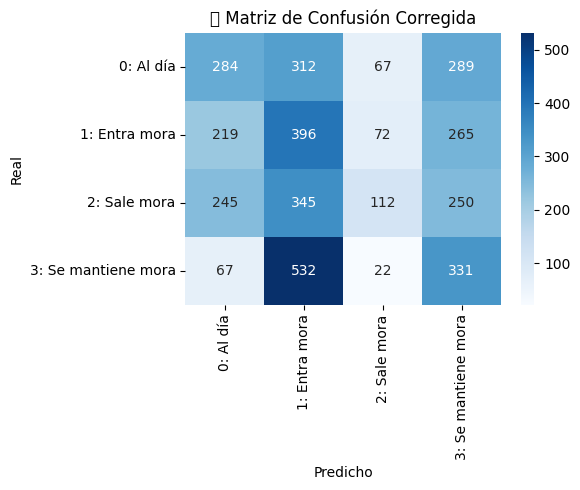

In [31]:
# -----------------------------
# 8. Reporte Final
# -----------------------------
print("\U0001F4CB Reporte de Clasificación (corregido):")
print(classification_report(y_true, y_pred_corr, target_names=["0: Al día", "1: Entra mora", "2: Sale mora", "3: Se mantiene mora"]))

cm = confusion_matrix(y_true, y_pred_corr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["0: Al día", "1: Entra mora", "2: Sale mora", "3: Se mantiene mora"],
            yticklabels=["0: Al día", "1: Entra mora", "2: Sale mora", "3: Se mantiene mora"])
plt.title("\U0001F501 Matriz de Confusión Corregida")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.tight_layout()
plt.show()